# Tema 1 IA - Introducere în Machine Learning


## Importuri

In [227]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Citirea datelor

In [228]:
train_df = pd.read_csv("CD_education_economy.csv")
val_df = pd.read_csv("CD_education_economy_test.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (64000, 14)
Validation shape: (16000, 14)


## Primele rânduri

In [229]:
display(train_df.head())
display(val_df.head())

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,proficiencies,aggregated_score,experience_bracket,vacation
0,Backend Developer,19,High School,12,Media,Large,USA,Yes,NaN,203997,11,0.151209,high,Small
1,Backend Developer,4,High School,13,Telecom,Small,Germany,Hybrid,NaN,116239,13,-0.031356,low,No Vacation
2,Backend Developer,8,High School,16,Retail,Enterprise,Remote,No,NaN,145802,16,1.914181,mid,No Vacation
3,Backend Developer,12,High School,9,Telecom,Enterprise,USA,Hybrid,NaN,190299,9,-0.392696,mid,Small
4,Backend Developer,14,High School,6,Telecom,Large,UK,Hybrid,4.0,152679,6,-1.906467,high,No Vacation


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,proficiencies,aggregated_score,experience_bracket,vacation
0,Software Engineer,20,Master,19,Finance,Startup,Australia,Yes,3.0,149046,19,1.694768,high,Small
1,Cloud Engineer,4,PhD,4,Consulting,Small,Remote,Hybrid,NaN,135069,4,-0.495076,low,Small
2,Software Engineer,6,Master,14,Technology,Large,Remote,Hybrid,2.0,145767,14,-0.698659,low,Small
3,Software Engineer,18,Master,17,Consulting,Startup,India,No,NaN,109203,17,0.745300,high,Small
4,Machine Learning Engineer,9,PhD,8,Healthcare,Small,Remote,Yes,3.0,158449,8,-0.276935,mid,Small


## Informații generale

In [230]:
print("=== TRAIN INFO ===")
print(train_df.info())

print("\n=== VALIDATION INFO ===")
print(val_df.info())

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           64000 non-null  object 
 1   experience_years    64000 non-null  int64  
 2   education_level     64000 non-null  object 
 3   skills_count        64000 non-null  int64  
 4   industry            64000 non-null  object 
 5   company_size        64000 non-null  object 
 6   location            64000 non-null  object 
 7   remote_work         64000 non-null  object 
 8   certifications      44853 non-null  float64
 9   salary              64000 non-null  int64  
 10  proficiencies       64000 non-null  int64  
 11  aggregated_score    64000 non-null  float64
 12  experience_bracket  64000 non-null  object 
 13  vacation            64000 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 6.8+ MB
None

=== VALIDATION INFO 

## Coloane și tipuri

In [231]:
print("Coloane:")
print(train_df.columns.tolist())

print("\nTipuri de date:")
print(train_df.dtypes)

Coloane:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary', 'proficiencies', 'aggregated_score', 'experience_bracket', 'vacation']

Tipuri de date:
job_title              object
experience_years        int64
education_level        object
skills_count            int64
industry               object
company_size           object
location               object
remote_work            object
certifications        float64
salary                  int64
proficiencies           int64
aggregated_score      float64
experience_bracket     object
vacation               object
dtype: object


## Valori lipsă

In [232]:
print("Valori lipsă în train:")
display(train_df.isna().sum().sort_values(ascending=False))

print("Valori lipsă în validation:")
display(val_df.isna().sum().sort_values(ascending=False))

Valori lipsă în train:


certifications        19147
job_title                 0
experience_years          0
education_level           0
skills_count              0
industry                  0
company_size              0
location                  0
remote_work               0
salary                    0
proficiencies             0
aggregated_score          0
experience_bracket        0
vacation                  0
dtype: int64

Valori lipsă în validation:


certifications        4780
job_title                0
experience_years         0
education_level          0
skills_count             0
industry                 0
company_size             0
location                 0
remote_work              0
salary                   0
proficiencies            0
aggregated_score         0
experience_bracket       0
vacation                 0
dtype: int64

## Separarea feature-urilor și țintelor

In [233]:
# Coloanele țintă pentru clasificare și regresie
target_classification = "vacation"
target_regression = "salary"

# Coloanele pentru atribute
feature_columns = [col for col in train_df.columns if col not in [target_classification, target_regression]]

# Construire seturi de date

# Datele de antrenare și validare
X_train = train_df[feature_columns].copy()
X_val = val_df[feature_columns].copy()

# Țintele pentru clasificare

# Valorile reale pentru antrenare
y_train_cls = train_df[target_classification].copy()
# Valorile reale pentru validare
y_val_cls = val_df[target_classification].copy()

# Țintele pentru regresie

# Valorile reale pentru antrenare
y_train_reg = train_df[target_regression].copy()
# Valorile reale pentru validare
y_val_reg = val_df[target_regression].copy()

print("Features:", feature_columns)

Features: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'proficiencies', 'aggregated_score', 'experience_bracket']


## Identificarea atributelor numerice și categoriale

In [234]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['experience_years', 'skills_count', 'certifications', 'proficiencies', 'aggregated_score']
Categorical features: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'experience_bracket']


## 1. Explorarea datelor (EDA)

## Statistici pentru atribute numerice

In [235]:
numeric_stats = X_train[numeric_features].describe().T
numeric_stats["nr_ex_fara_val_lipsa"] = X_train[numeric_features].notna().sum()

display(numeric_stats[["nr_ex_fara_val_lipsa", "mean", "std", "min", "25%", "50%", "75%", "max"]])

,nr_ex_fara_val_lipsa,mean,std,min,25%,50%,75%,max
experience_years,64000,11.615703,11.031172,0.00000,5.000000,10.00000,16.00000,69.000000
skills_count,64000,9.974469,5.479935,1.00000,5.000000,10.00000,15.00000,19.000000
certifications,44853,2.497180,1.708064,0.00000,1.000000,3.00000,4.00000,5.000000
proficiencies,64000,9.950859,5.451872,1.00000,5.000000,10.00000,15.00000,19.000000
aggregated_score,64000,-0.004506,1.003307,-4.35271,-0.676323,-0.00686,0.67447,4.226987


## Statistici pentru atribute categoriale

In [236]:
categorical_stats = pd.DataFrame({
    "nr_ex_fara_val_lipsa": X_train[categorical_features].notna().sum(),
    "nr_val_unice": X_train[categorical_features].nunique()
})

display(categorical_stats)

,nr_ex_fara_val_lipsa,nr_val_unice
job_title,64000,12
education_level,64000,5
industry,64000,10
company_size,64000,5
location,64000,10
remote_work,64000,3
experience_bracket,64000,3


## Boxplot pentru fiecare atribut numeric

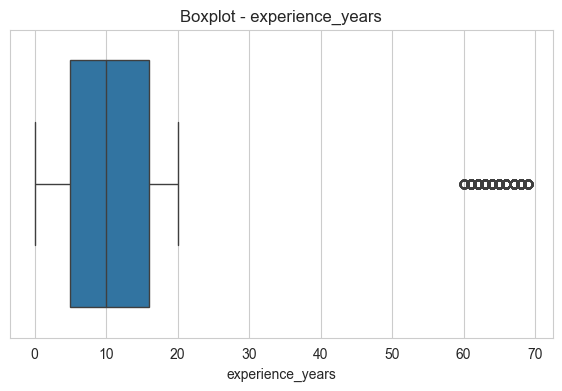

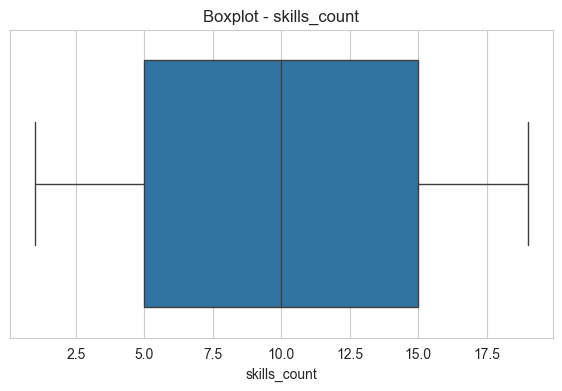

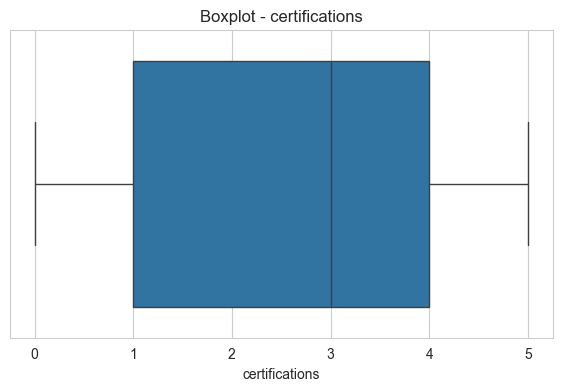

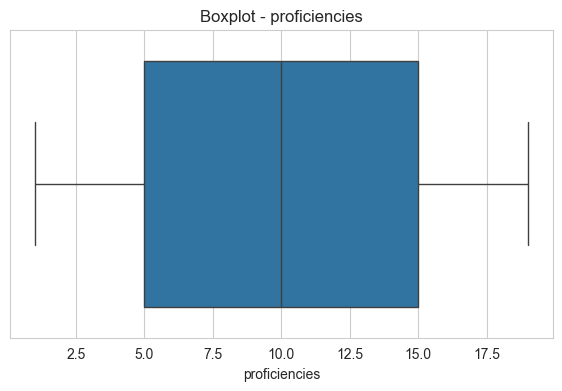

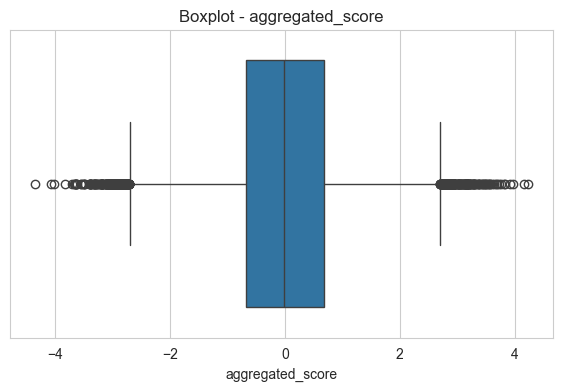

In [237]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

## Histograme pentru atribute numerice

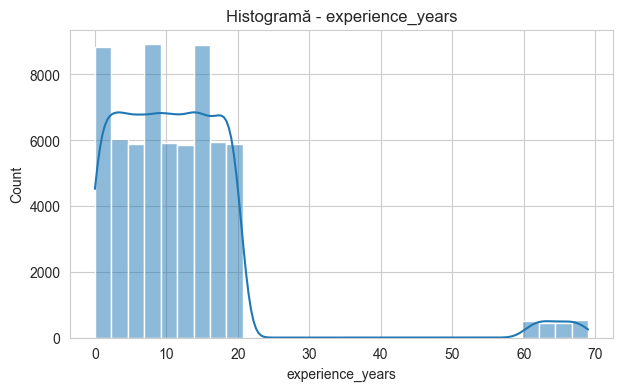

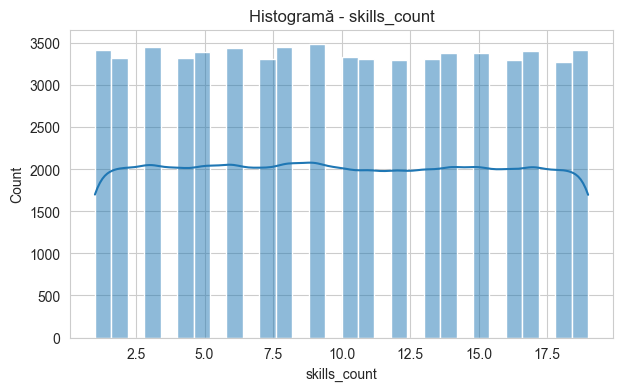

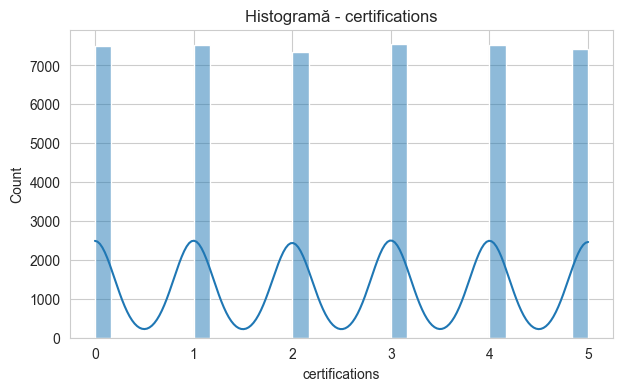

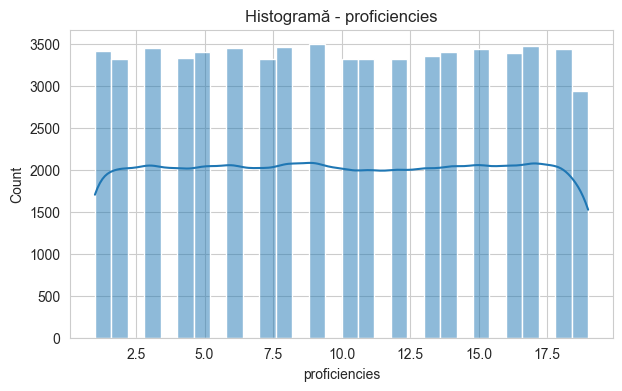

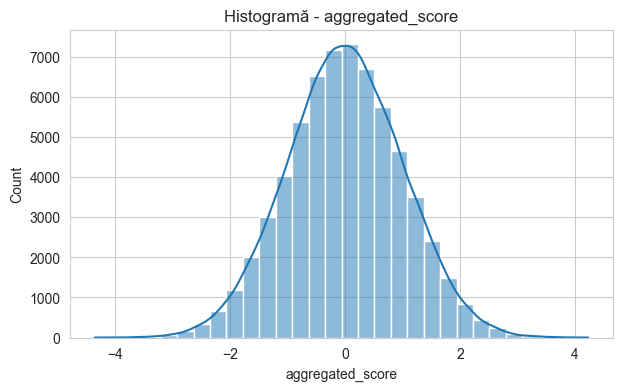

In [238]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f"Histogramă - {col}")
    plt.show()

## Countplot pentru atribute categorice

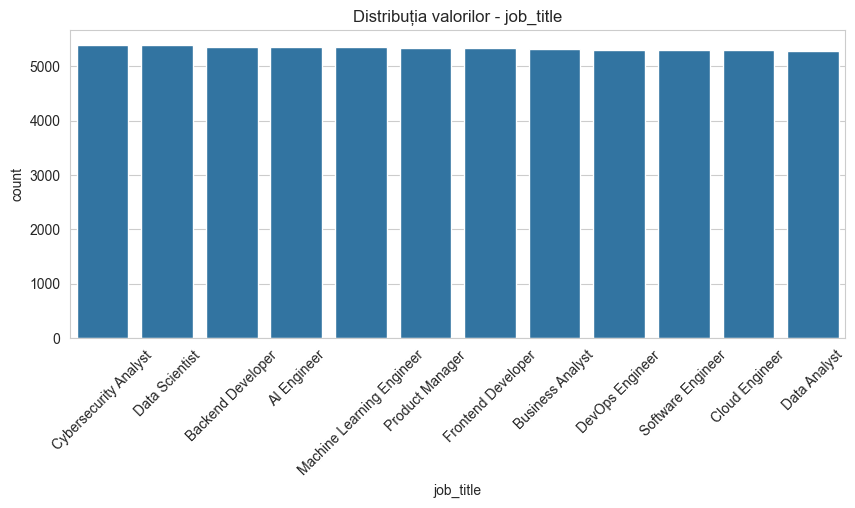

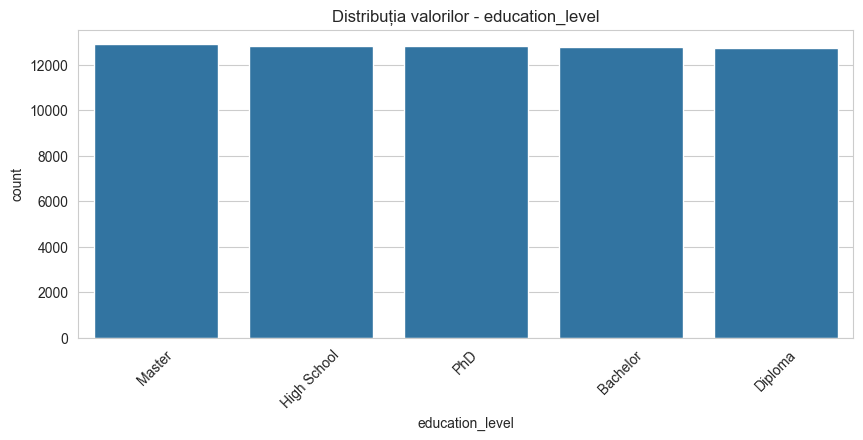

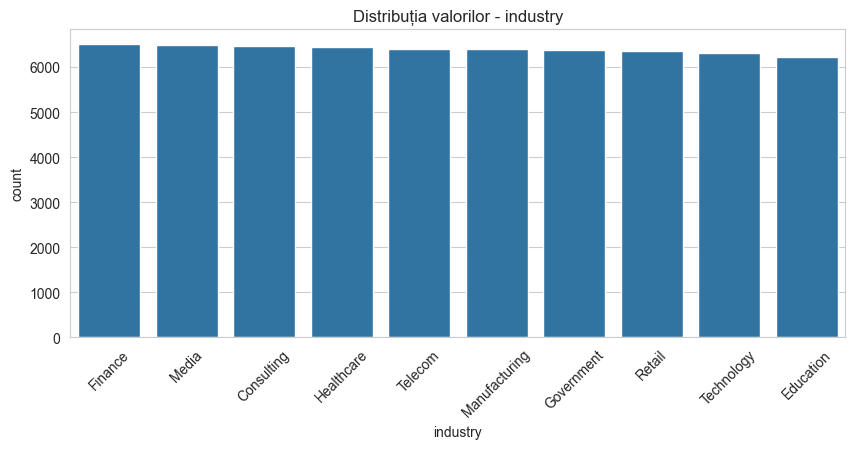

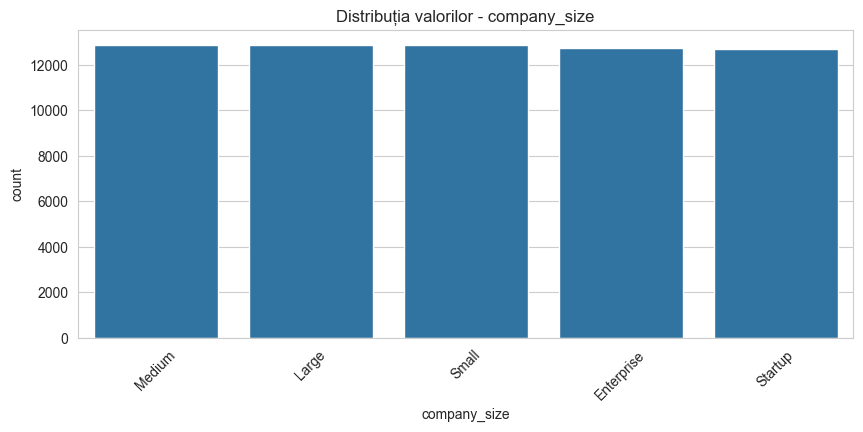

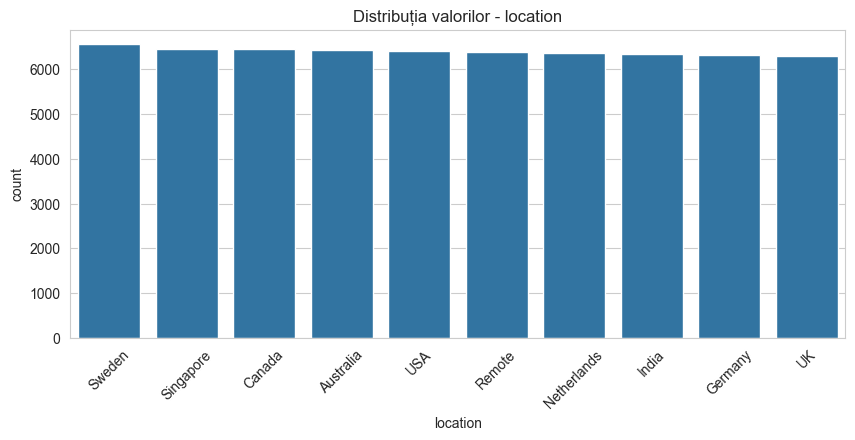

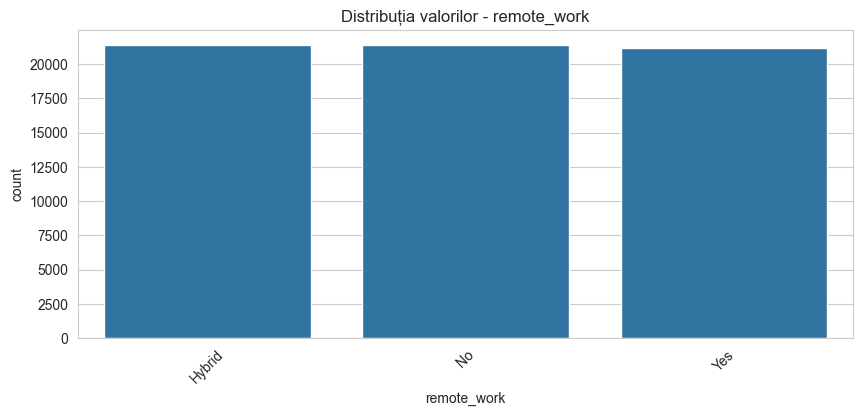

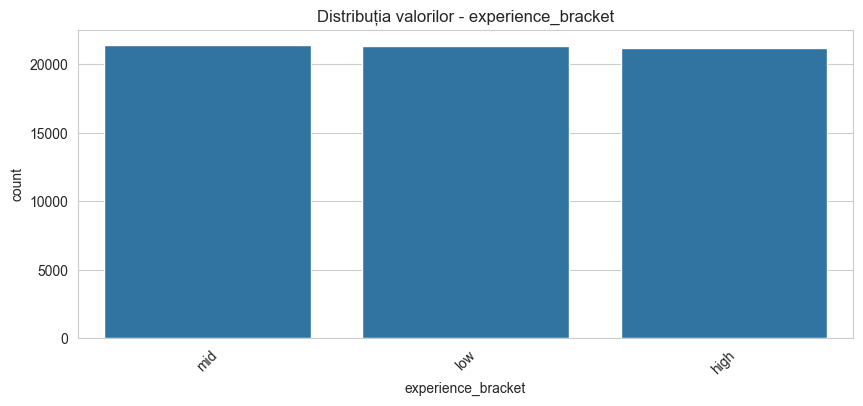

In [239]:
for col in categorical_features:
    plt.figure(figsize=(10, 4))
    order = X_train[col].value_counts().index
    sns.countplot(data=X_train, x=col, order=order)
    plt.title(f"Distribuția valorilor - {col}")
    plt.xticks(rotation=45)
    plt.show()

## Distribuția claselor pentru vacation

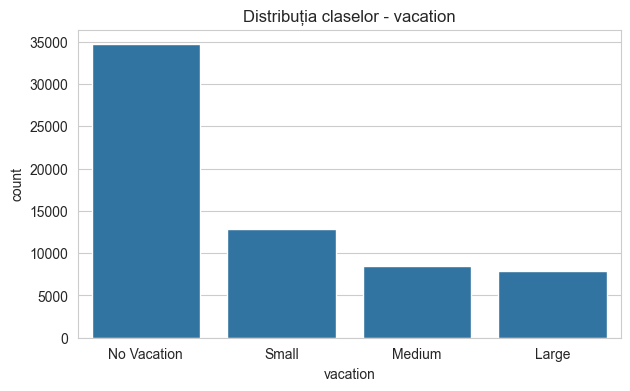

vacation
No Vacation    34674
Small          12886
Medium          8530
Large           7910
Name: count, dtype: int64

vacation
No Vacation    54.18
Small          20.13
Medium         13.33
Large          12.36
Name: proportion, dtype: float64

In [240]:
plt.figure(figsize=(7, 4))
order = y_train_cls.value_counts().index
sns.countplot(x=y_train_cls, order=order)
plt.title("Distribuția claselor - vacation")
plt.show()

display(y_train_cls.value_counts())
display((y_train_cls.value_counts(normalize=True) * 100).round(2))

## Distribuția lui salary

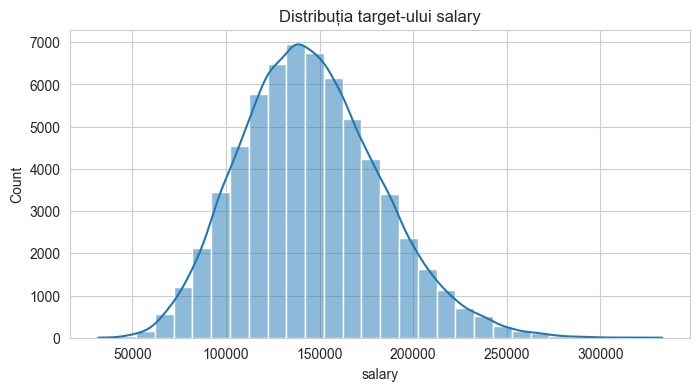

In [241]:
plt.figure(figsize=(8, 4))
sns.histplot(y_train_reg, kde=True, bins=30)
plt.title("Distribuția target-ului salary")
plt.show()

## Corelația între atribuțiile numerice

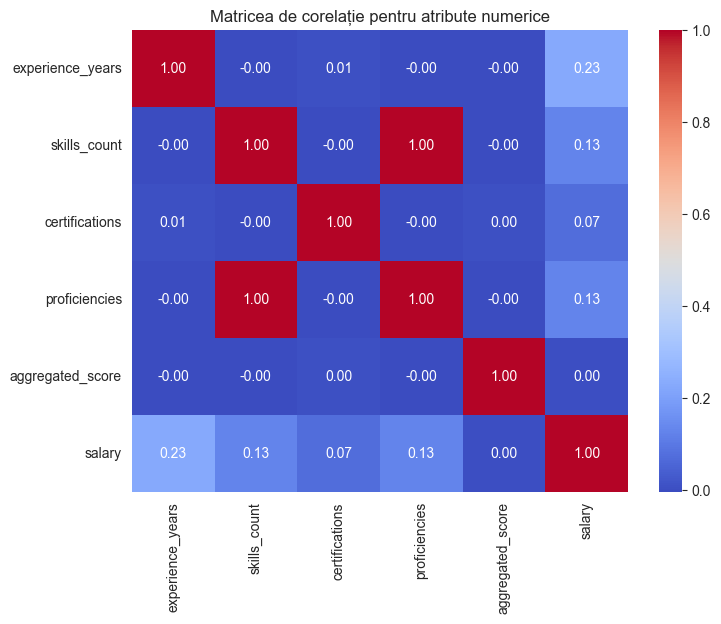

In [242]:
corr_matrix = train_df[numeric_features + [target_regression]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matricea de corelație pentru atribute numerice")
plt.show()

## Corelație între atributele numerice și salary

In [243]:
corr_with_salary = train_df[numeric_features].corrwith(y_train_reg).sort_values(ascending=False)
corr_with_salary_df = corr_with_salary.reset_index()
corr_with_salary_df.columns = ["Atribut", "Corelație cu Salary"]

display(corr_with_salary_df)

,Atribut,Corelație cu Salary
0,experience_years,0.229356
1,skills_count,0.128878
2,proficiencies,0.128757
3,certifications,0.072667
4,aggregated_score,0.001170


## Corelație între atributele numerice și vacation

In [244]:
label_encoder_temp = LabelEncoder()
y_train_cls_encoded_temp = label_encoder_temp.fit_transform(y_train_cls)

corr_with_vacation = train_df[numeric_features].corrwith(pd.Series(y_train_cls_encoded_temp)).sort_values(ascending=False)
corr_with_vacation_df = corr_with_vacation.reset_index()
corr_with_vacation_df.columns = ["Atribut", "Corelație cu Vacation"]

display(corr_with_vacation_df)

,Atribut,Corelație cu Vacation
0,certifications,-0.001088
1,aggregated_score,-0.001833
2,proficiencies,-0.004704
3,skills_count,-0.004806
4,experience_years,-0.398735


## Relație numeric -> vacation

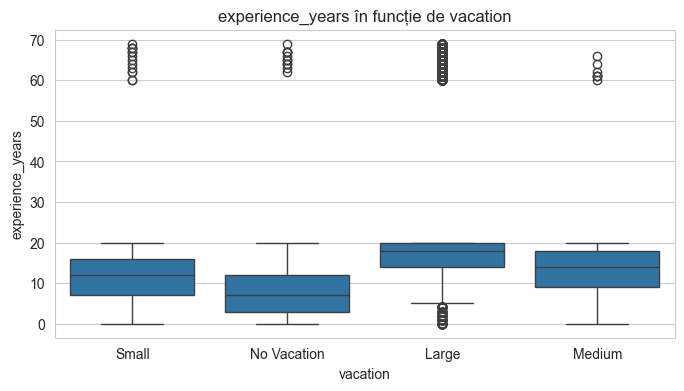

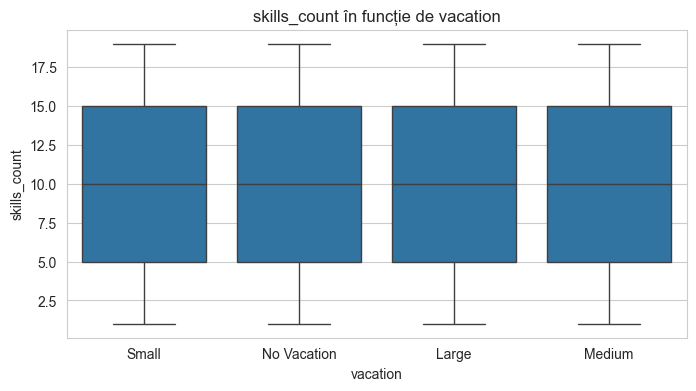

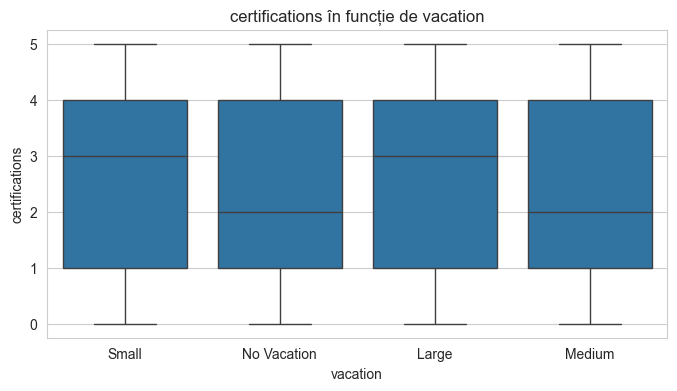

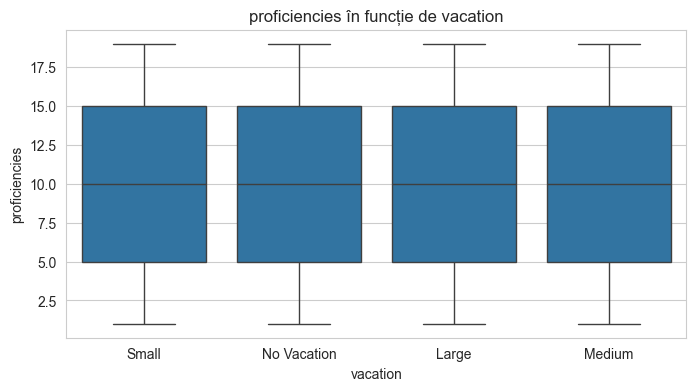

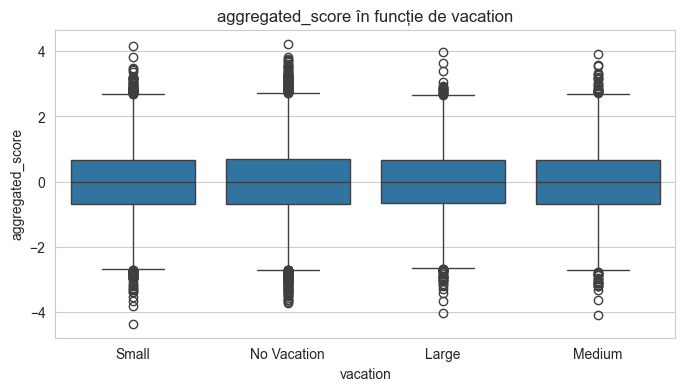

In [245]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train_df, x=target_classification, y=col)
    plt.title(f"{col} în funcție de vacation")
    plt.show()

## Relație categorical -> vacation

<Figure size 1000x400 with 0 Axes>

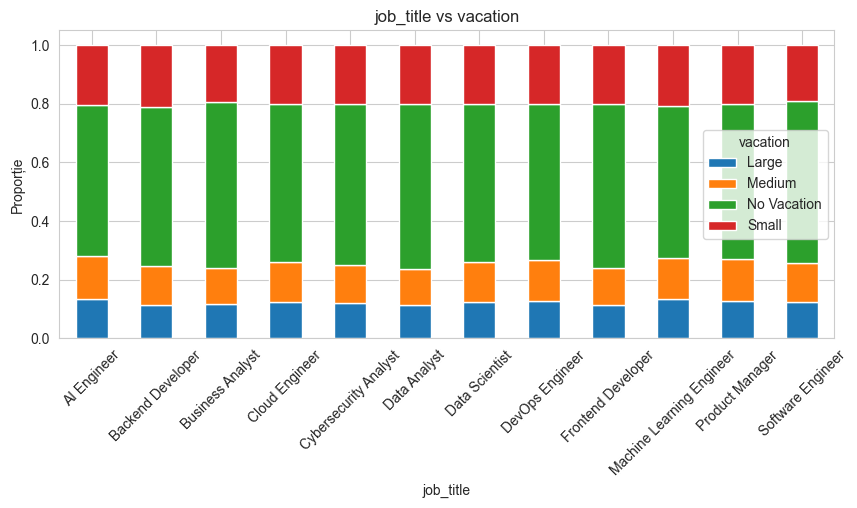

<Figure size 1000x400 with 0 Axes>

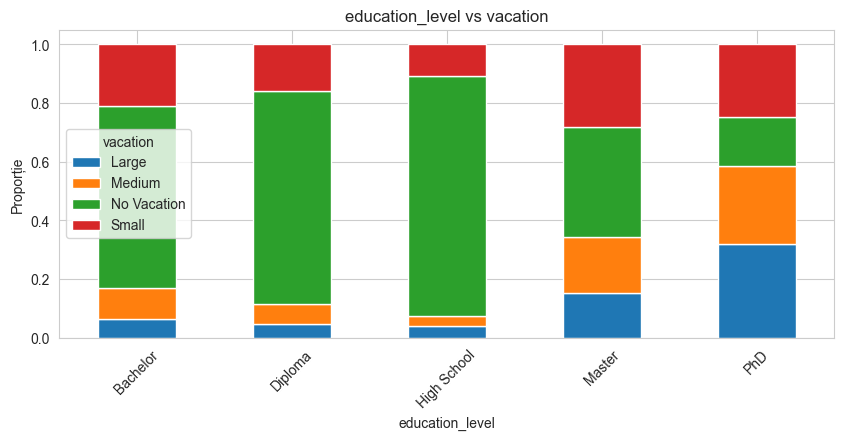

<Figure size 1000x400 with 0 Axes>

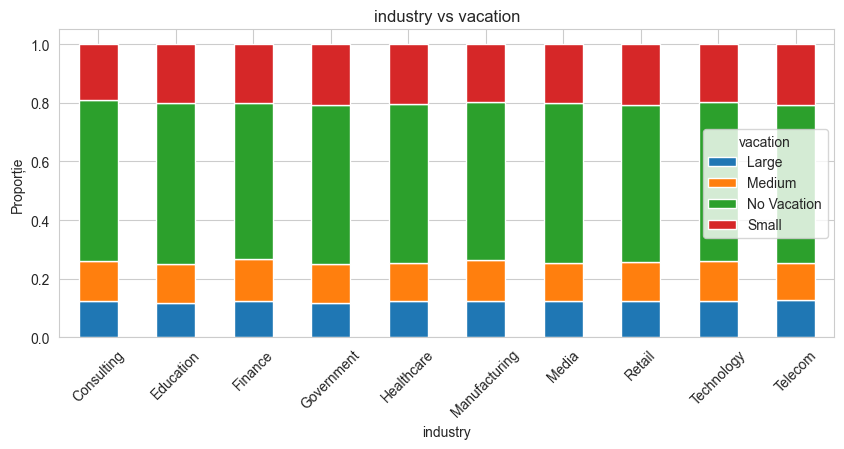

<Figure size 1000x400 with 0 Axes>

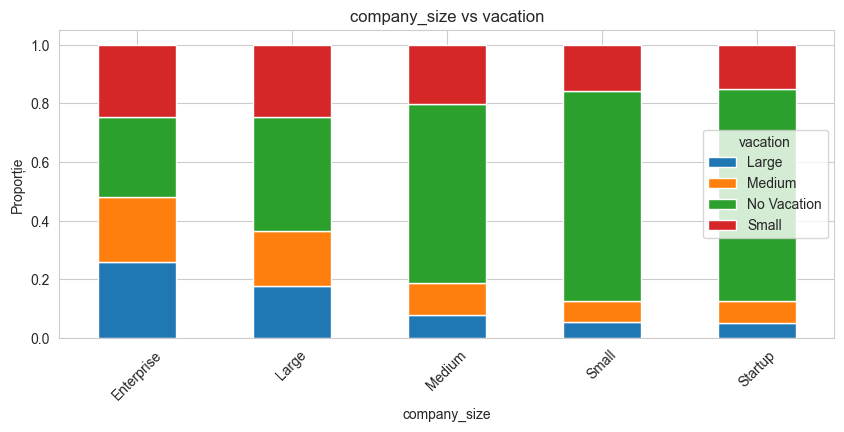

<Figure size 1000x400 with 0 Axes>

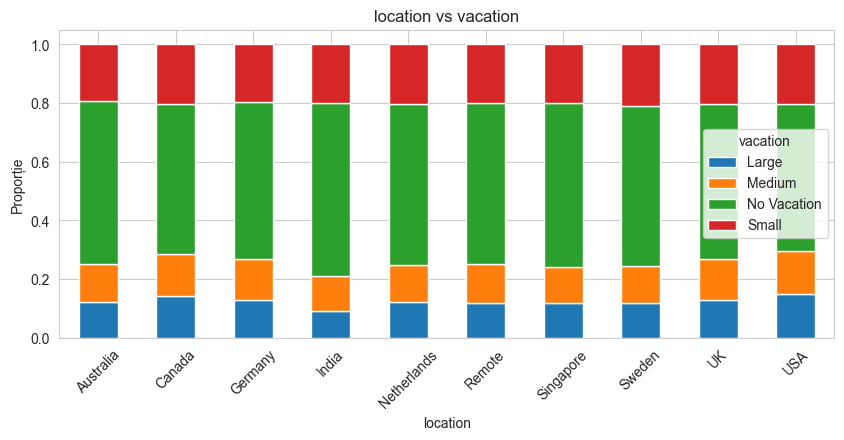

<Figure size 1000x400 with 0 Axes>

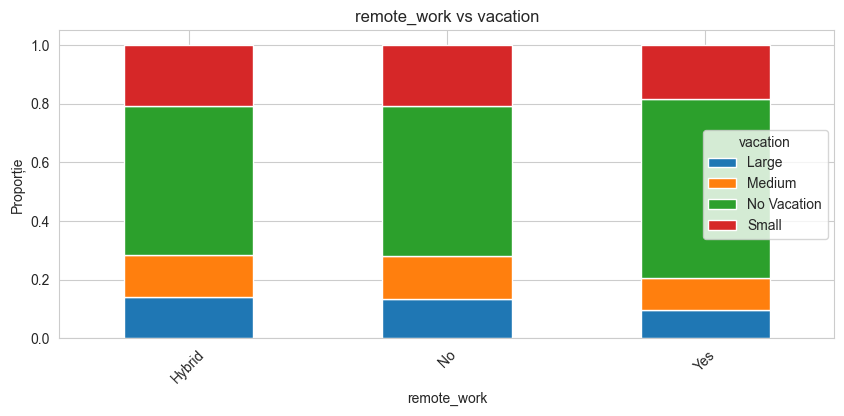

<Figure size 1000x400 with 0 Axes>

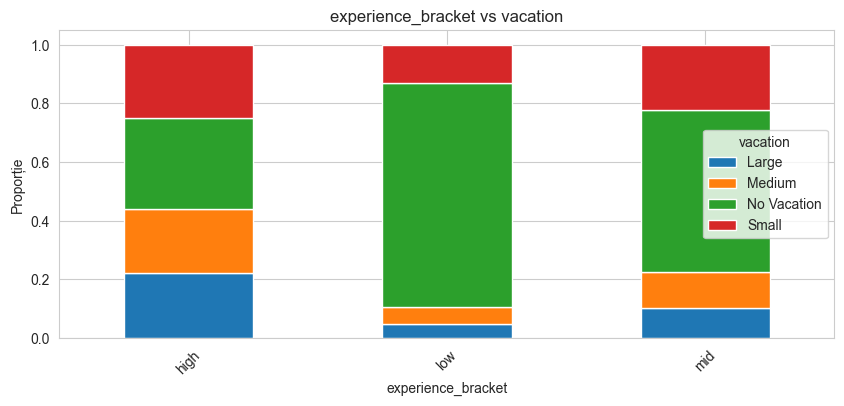

In [246]:
for col in categorical_features:
    plt.figure(figsize=(10, 4))
    cross = pd.crosstab(train_df[col], train_df[target_classification], normalize="index")
    cross.plot(kind="bar", stacked=True, figsize=(10, 4))
    plt.title(f"{col} vs vacation")
    plt.ylabel("Proporție")
    plt.xticks(rotation=45)
    plt.show()

## Relație numeric -> salary

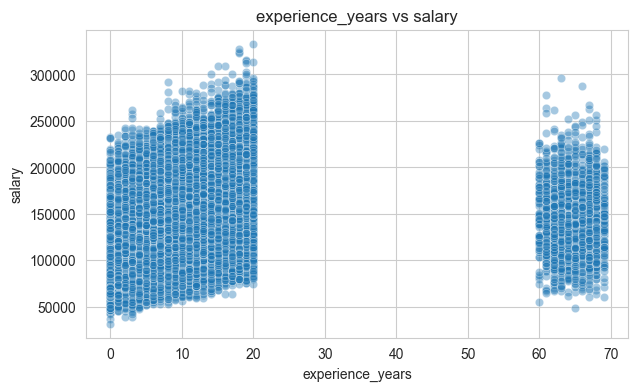

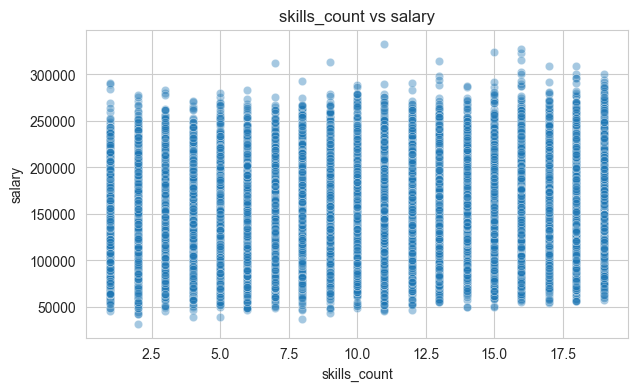

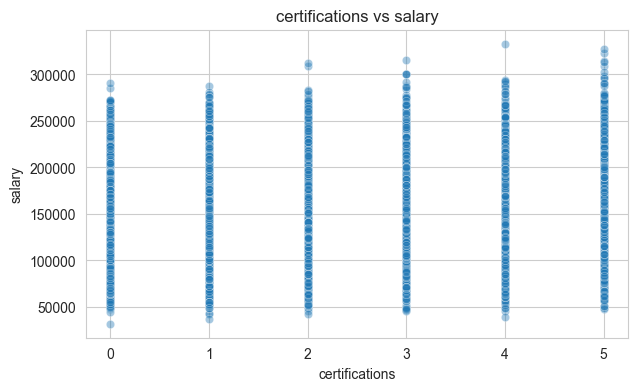

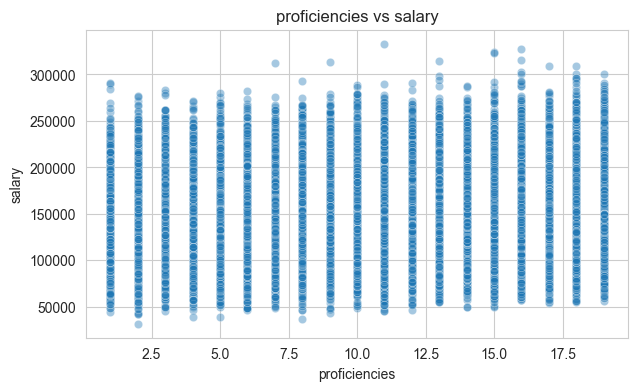

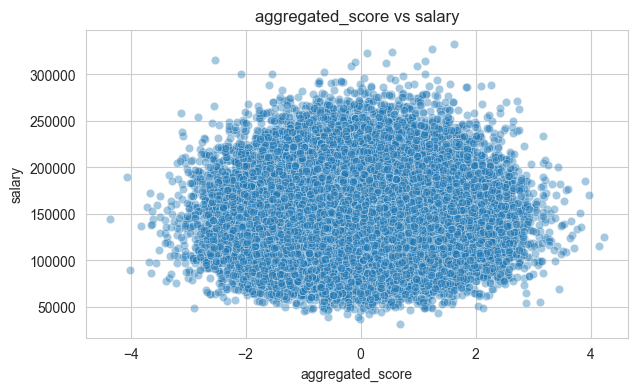

In [247]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=train_df[col], y=train_df[target_regression], alpha=0.4)
    plt.title(f"{col} vs salary")
    plt.show()

## Relație categorical -> salary

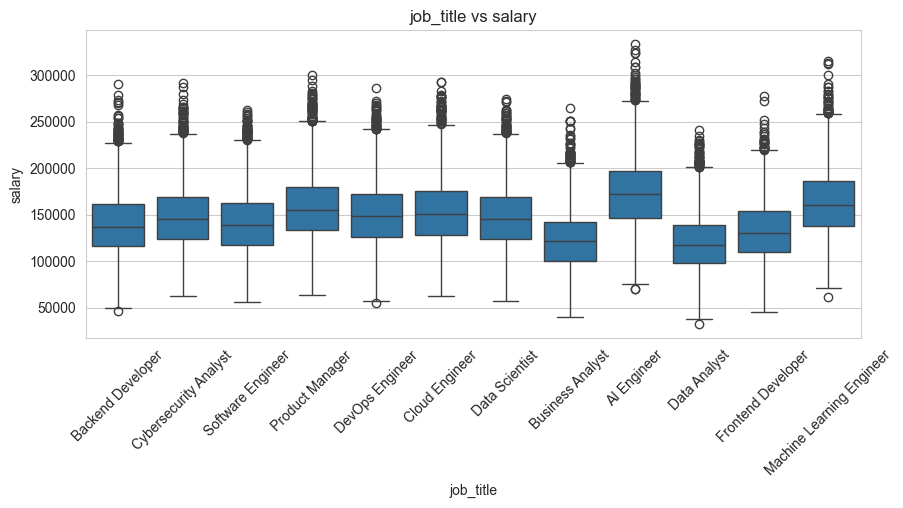

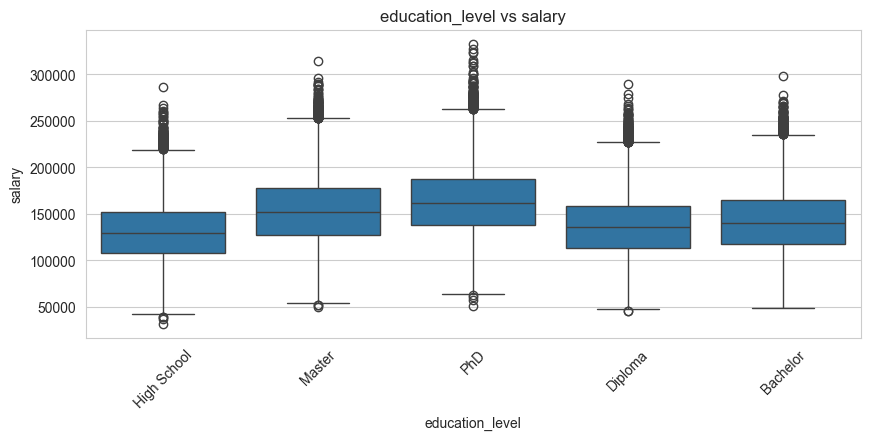

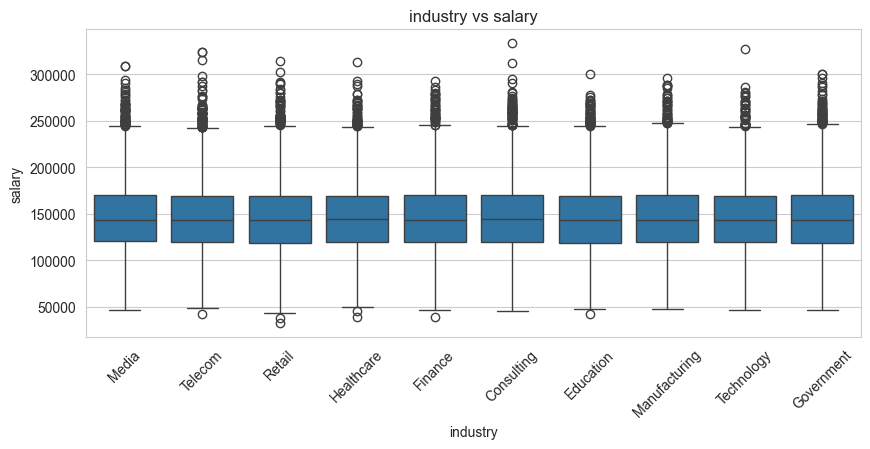

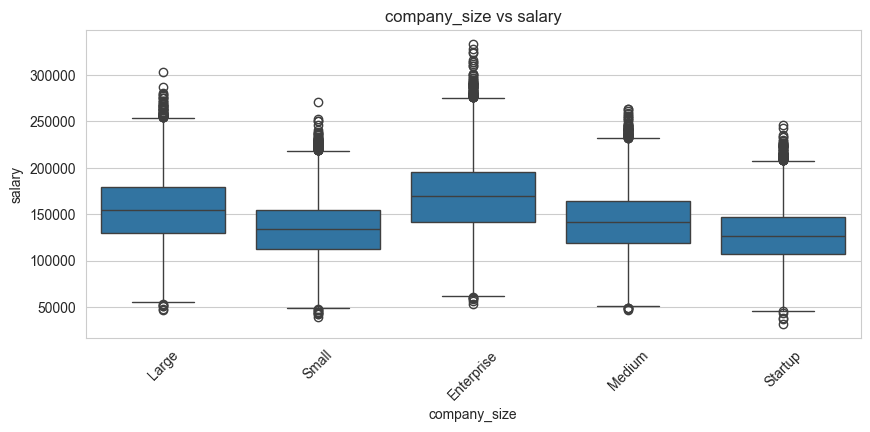

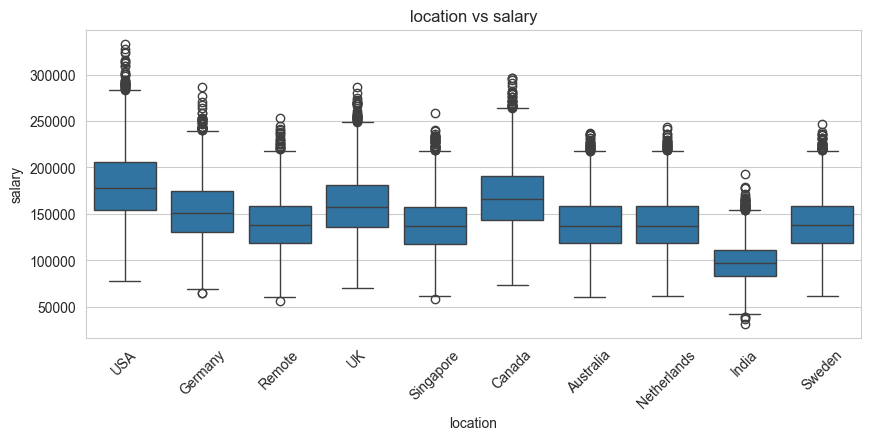

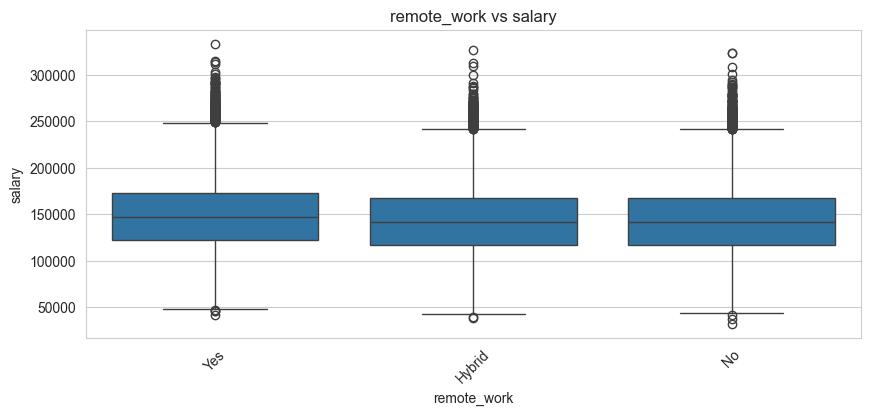

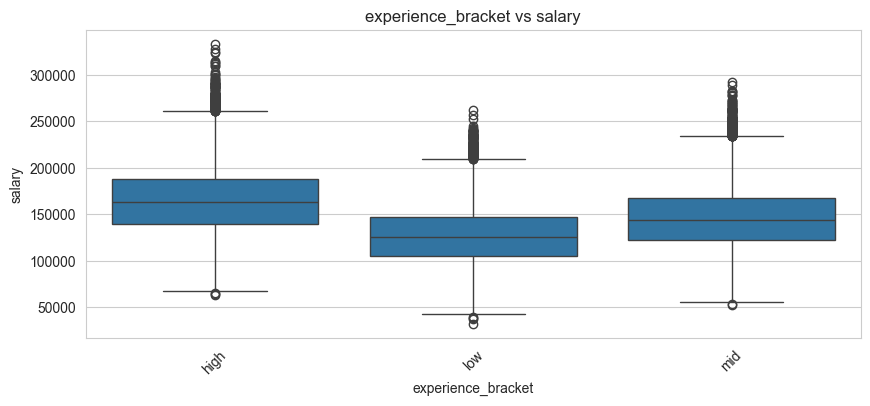

In [248]:
for col in categorical_features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=train_df, x=col, y=target_regression)
    plt.title(f"{col} vs salary")
    plt.xticks(rotation=45)
    plt.show()

## 2. Preprocesarea datelor

## Funcție pentru identificarea outlierilor prin IQR

In [249]:
def detect_outliers_iqr(df, columns):
    # Dicționar pentru informațiile despre outlieri pentru fiecare coloană
    outlier_info = {}

    # Pentru fiecare coloană numerică primită ca parametru:
    # - calculez prima și a treia quartilă
    # - calculez intervlul dintre ele
    # - calculez limita inferioară și superioară pentru outlieri
    # - construiesc o mască booleană cu true pentru valorile in afara limitelor
    # - salvez limitele și numărul de outlieri detectați
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_info[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": mask.sum()
        }

    # Transform dicționarul într-un DataFrame și îl transpun ca
    # fiecare rând să corespundă unei coloane
    return pd.DataFrame(outlier_info).T

## Outlieri în train

In [250]:
outlier_table = detect_outliers_iqr(train_df, numeric_features)
display(outlier_table)

,lower_bound,upper_bound,outlier_count
experience_years,-11.500000,32.50000,1903.0
skills_count,-10.000000,30.00000,0.0
certifications,-3.500000,8.50000,0.0
proficiencies,-10.000000,30.00000,0.0
aggregated_score,-2.702512,2.70066,416.0


## Funcție de clipping pe baza IQR

In [251]:
def cap_outliers_iqr(train_data, val_data, columns):
    # Fac copii ale datelor
    train_capped = train_data.copy()
    val_capped = val_data.copy()

    # Pentru fiecare coloană numerică:
    # - calculez quartilele 1 și 3
    # - calculez intervalul dintre ele
    # - stabilesc limitele pentru valori normale
    # - fac clipping pe train (val mai mici de limita inf devin lower_bound, iar cele mai mari decât limita sup devin upper_bound)
    # - aplic aceleași limite și pe validare
    for col in columns:
        q1 = train_data[col].quantile(0.25)
        q3 = train_data[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        train_capped[col] = train_capped[col].clip(lower=lower_bound, upper=upper_bound)
        val_capped[col] = val_capped[col].clip(lower=lower_bound, upper=upper_bound)

    return train_capped, val_capped

## Aplicare clipping pe outlieri

In [252]:
X_train_capped, X_val_capped = cap_outliers_iqr(X_train, X_val, numeric_features)

print("Outlier handling done.")

Outlier handling done.


## Encoding pentru target-ul de clasificare

In [253]:
# Creez un encoder pentru variabila țintă de clasificare
label_encoder_cls = LabelEncoder()

# Aplic fit + transform pe setul de train
# - învață clasele (Large, Medium, Small, No vacation) și le transformă în valori numerice
y_train_cls_encoded = label_encoder_cls.fit_transform(y_train_cls)
# Aplic doar transform pe validation
y_val_cls_encoded = label_encoder_cls.transform(y_val_cls)

print("Clase vacation:", label_encoder_cls.classes_)

Clase vacation: ['Large' 'Medium' 'No Vacation' 'Small']


## Preprocesor pentru clasificare și regresie

In [254]:
# Pipeline pentru preprocesarea atributelor numerice
numeric_transformer = Pipeline(steps=[
    # Completez valorile lipsă din coloanele numerice cu mediana fiecărei coloane
    ("imputer", SimpleImputer(strategy="median")),
    # Standardizez valorile numerice astfel încât să aibă media 0 și deviația standard 1
    ("scaler", StandardScaler())
])

# Pipeline pentru preprocesarea atributelor categoriale
categorical_transformer = Pipeline(steps=[
    # Completez valorile lipsă din coloanele categoriale cu cea mai frecventă valoare
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # Transform valorile categoriale în valori numerice prin One-Hot Encoding și evit erorile dacă în validation apare o categorie nouă
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#  Cu ColumnTransformer aplic transformări diferite pe tipuri diferite de coloane
preprocessor = ColumnTransformer(transformers=[
    # Aplic pipeline-ul numeric pe coloanele numerice
    ("num", numeric_transformer, numeric_features),
    # Aplic pipeline-ul categorial pe coloanele categoriale
    ("cat", categorical_transformer, categorical_features)
])

## 3. Clasificare - predicția lui `vacation`

## Dicționar cu modele de clasificare

In [255]:
# Dicționar cu mai multe modele de clasificare
classification_models = {
    # Arbore de decizie cu adâncime maximă 5
    "DecisionTree_depth5": DecisionTreeClassifier(max_depth=5, random_state=42),
    # Arbore de decizie cu adâncime maximă 10
    "DecisionTree_depth10": DecisionTreeClassifier(max_depth=10, random_state=42),
    # Arbore cu constrângere pe numărul minim de exemple din frunză (pentru a reduce overfitting)
    "DecisionTree_leaf5": DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42),
    # Regresie logistică
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    # Random forest cu 200 de arbori, adâncime maximă 10, care folosește toate nucleele de procesare
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
}

## Antrenare și evaluare modele de clasificare

In [256]:
# Lista cu rezultatele de la fiecare model
classification_results = []
# Dicționar unde salvez pipeline-ul și predicțiile fiecărui model
classification_predictions = {}

# Pentru fiecare model definit anterior:
# - construiesc pipeline-ul complet cu preprocesare și modelul de învățare
# - antrenez modelul pe datele de train (după clipping)
# - face predicții pe setul de validare
# - calculez metricile de evaluare
# - Calculez Precision, Recall și F1 (macro = medie pe clase)
# - Salvez rezultatele într-un dicționar
# - Salvez pipeline-ul și predicțiile (pentru Kaggle)
for model_name, model in classification_models.items():
    clf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    clf_pipeline.fit(X_train_capped, y_train_cls_encoded)
    y_pred = clf_pipeline.predict(X_val_capped)

    acc = accuracy_score(y_val_cls_encoded, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val_cls_encoded, y_pred, average="macro")

    classification_results.append({
        "Model": model_name,
        "Acuratețe": acc,
        "Precizie": precision,
        "Recall": recall,
        "F1": f1
    })

    classification_predictions[model_name] = {
        "pipeline": clf_pipeline,
        "predictions": y_pred
    }

# Transform lista de rezultate într-un DataFrame și sortez după F1
classification_results_df = pd.DataFrame(classification_results).sort_values(by="F1", ascending=False)
display(classification_results_df)

,Model,Acuratețe,Precizie,Recall,F1
3,LogisticRegression,0.777750,0.709958,0.685770,0.696173
2,DecisionTree_leaf5,0.766500,0.701810,0.682289,0.691400
1,DecisionTree_depth10,0.764875,0.698908,0.679515,0.688560
4,RandomForest,0.751500,0.687742,0.640484,0.659222
0,DecisionTree_depth5,0.708000,0.640605,0.590069,0.610019


## Cel mai bun model de clasificare

In [257]:
# Aleg numele celui mai bun model (primul din tabel, deja sortat după F1)
best_classification_model_name = classification_results_df.iloc[0]["Model"]
# Iau pipeline-ul complet (preprocesare + model)
best_classification_pipeline = classification_predictions[best_classification_model_name]["pipeline"]
# Iau predicțiile făcute pe validation set
best_classification_pred = classification_predictions[best_classification_model_name]["predictions"]

print("Best classification model:", best_classification_model_name)

Best classification model: LogisticRegression


## Classification report

In [258]:
# Afișez un raport detaliat pentru fiecare clasă
print(classification_report(
    y_val_cls_encoded,
    best_classification_pred,
    target_names=label_encoder_cls.classes_
))

              precision    recall  f1-score   support

       Large       0.81      0.77      0.79      1978
      Medium       0.57      0.47      0.51      2132
 No Vacation       0.88      0.93      0.90      8669
       Small       0.58      0.57      0.58      3221

    accuracy                           0.78     16000
   macro avg       0.71      0.69      0.70     16000
weighted avg       0.77      0.78      0.77     16000



## Matrice de confuzie

<Figure size 700x600 with 0 Axes>

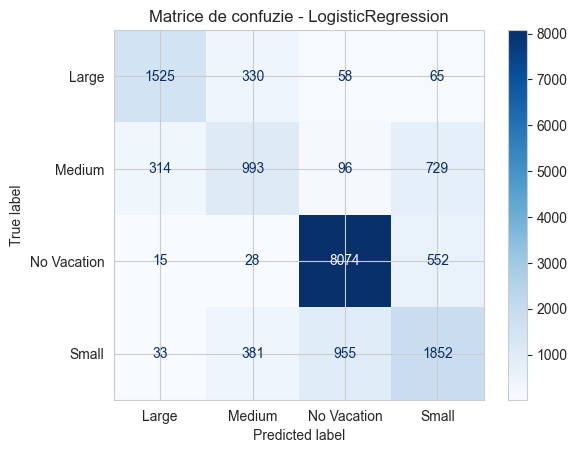

In [259]:
# Calculez matricea de confuzie pentru cel mai bun model de clasificare
# y_val_cls_encoded = clasele reale din setul de validare
# best_classification_pred = clasele prezise de model
cm = confusion_matrix(y_val_cls_encoded, best_classification_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder_cls.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matrice de confuzie - {best_classification_model_name}")
plt.show()

## Tabel detaliat pe clase

In [260]:
# Calculez metricile pentru fiecare clasă separat
# average=None => obținem valori pentru fiecare clasă individual
precision, recall, f1, support = precision_recall_fscore_support(
    y_val_cls_encoded, best_classification_pred, average=None
)

# Construiesc un DataFrame pentru afișare mai clară
per_class_metrics_df = pd.DataFrame({
    "Class": label_encoder_cls.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

display(per_class_metrics_df)

,Class,Precision,Recall,F1,Support
0,Large,0.808161,0.770981,0.789133,1978
1,Medium,0.573326,0.465760,0.513975,2132
2,No Vacation,0.879233,0.931365,0.904549,8669
3,Small,0.579112,0.574977,0.577037,3221


## 4. Regresie - predicția lui `salary`

## Dicționar cu modele de regresie

In [261]:
# Dicționar cu mai multe modele de regresie 
regression_models = {
    # Regresie Liniară simplă
    "LinearRegression": LinearRegression(),
    # Ridge Regression
    "Ridge_alpha_1": Ridge(alpha=1.0),
    # Ridge cu regularizare mai puternică
    "Ridge_alpha_10": Ridge(alpha=10.0),
    # Lasso Regression
    "Lasso_alpha_0.001": Lasso(alpha=0.001),
    # Random Forest Regressor cu 200 de arbori, adâncime maximă 10, seed fix și care folosește toate nucleele posibile
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
}

## Funcție metrici regresie

In [262]:
# Funcție care calculează principalele metrici pentru regresie
def regression_metrics(y_true, y_pred):
    # Media diferențelor absolute dintre valorile reale și cele prezise
    mae = mean_absolute_error(y_true, y_pred)
    # Media pătratelor erorilor; penalizează mai puternic erorile mari
    mse = mean_squared_error(y_true, y_pred)
    # Radical din MSE; are aceeași unitate de măsură ca target-ul salary
    rmse = np.sqrt(mse)
    # Măsoară cât de bine explică modelul variația datelor
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

## Antrenare și evaluare modele de regresie

In [263]:
# Listă cu rezultatele fiecărui model
regression_results = []
# Dicționar în care salvez pipeline-ul și predicțiile pentru fiecare model
regression_predictions = {}

for model_name, model in regression_models.items():
    # Construiesc un pipeline:
    # - preprocesare (imputare + scaling + encoding)
    # - modelul de regresie
    reg_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    # Antrenez modelul pe datele de train
    reg_pipeline.fit(X_train_capped, y_train_reg)
    # Face predicții pe setul de validare
    y_pred = reg_pipeline.predict(X_val_capped)

    # Calculez metricile de regresie
    mae, mse, rmse, r2 = regression_metrics(y_val_reg, y_pred)

    # Salvez rezultatele pentru acest model în dicționar
    regression_results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

    # Salvez pipeline-ul și predicțiile pentru utilizare ulterioară
    regression_predictions[model_name] = {
        "pipeline": reg_pipeline,
        "predictions": y_pred
    }

# Transform lista de rezultate într-un DataFrame
# și sortez după RMSE
regression_results_df = pd.DataFrame(regression_results).sort_values(by="RMSE", ascending=True)
display(regression_results_df)

,Model,MAE,MSE,RMSE,R2
2,Ridge_alpha_10,6820.873430,7.702505e+07,8776.391627,0.944740
1,Ridge_alpha_1,6822.300732,7.703385e+07,8776.893070,0.944733
0,LinearRegression,6822.609344,7.703617e+07,8777.025337,0.944732
3,Lasso_alpha_0.001,6822.801365,7.703826e+07,8777.144140,0.944730
4,RandomForestRegressor,12206.951173,2.421473e+08,15561.082804,0.826275


## Cel mai bun model de regresie

In [264]:
best_regression_model_name = regression_results_df.iloc[0]["Model"]
best_regression_pipeline = regression_predictions[best_regression_model_name]["pipeline"]
best_regression_pred = regression_predictions[best_regression_model_name]["predictions"]

print("Best regression model:", best_regression_model_name)

Best regression model: Ridge_alpha_10


## Grafic valori reale vs prezise

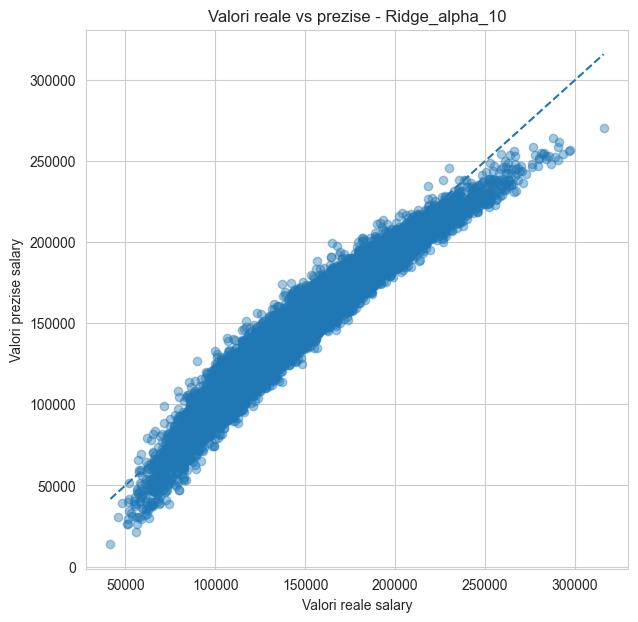

In [265]:
plt.figure(figsize=(7, 7))
plt.scatter(y_val_reg, best_regression_pred, alpha=0.4)
plt.xlabel("Valori reale salary")
plt.ylabel("Valori prezise salary")
plt.title(f"Valori reale vs prezise - {best_regression_model_name}")
plt.plot([y_val_reg.min(), y_val_reg.max()], [y_val_reg.min(), y_val_reg.max()], linestyle="--")
plt.show()

## Histograma erorilor

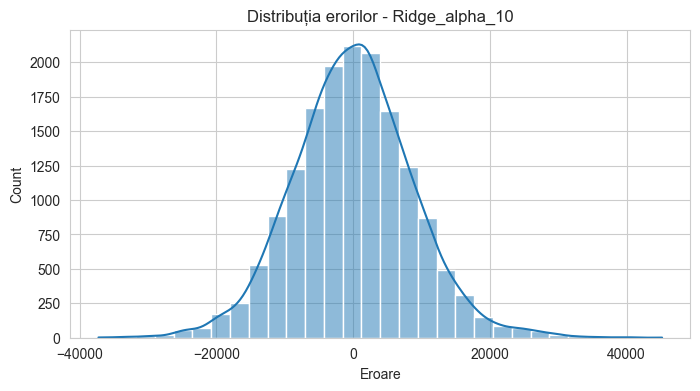

In [266]:
errors = y_val_reg - best_regression_pred

plt.figure(figsize=(8, 4))
sns.histplot(errors, kde=True, bins=30)
plt.title(f"Distribuția erorilor - {best_regression_model_name}")
plt.xlabel("Eroare")
plt.show()

## Grafic train vs validation pentru regresie

In [267]:
# Listă unde salvez rezultatele pentru train vs validation
train_val_regression_results = []

for model_name, model in regression_models.items():
    # Construiesc pipeline (preprocesare + model)
    reg_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    # Antrenez modelul pe train
    reg_pipeline.fit(X_train_capped, y_train_reg)

    # Predicții pe train
    train_pred = reg_pipeline.predict(X_train_capped)
    # Predicții pe validation
    val_pred = reg_pipeline.predict(X_val_capped)

    # Calculez metrici pentru train
    train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train_reg, train_pred)
    # Calculez metrici pentru validation
    val_mae, val_mse, val_rmse, val_r2 = regression_metrics(y_val_reg, val_pred)

    # Salvez rezultatele în dicționar
    train_val_regression_results.append({
        "Model": model_name,
        "Train_MAE": train_mae,
        "Val_MAE": val_mae,
        "Train_RMSE": train_rmse,
        "Val_RMSE": val_rmse,
        "Train_R2": train_r2,
        "Val_R2": val_r2
    })

# Transformăm în DataFrame pentru analiză ușoară
train_val_regression_df = pd.DataFrame(train_val_regression_results)
display(train_val_regression_df)

,Model,Train_MAE,Val_MAE,Train_RMSE,Val_RMSE,Train_R2,Val_R2
0,LinearRegression,6844.646883,6822.609344,8777.471092,8777.025337,0.944751,0.944732
1,Ridge_alpha_1,6844.539792,6822.300732,8777.495476,8776.893070,0.944751,0.944733
2,Ridge_alpha_10,6843.660286,6820.873430,8777.620322,8776.391627,0.944749,0.944740
3,Lasso_alpha_0.001,6844.708389,6822.801365,8777.495461,8777.144140,0.944751,0.944730
4,RandomForestRegressor,11817.981194,12206.951173,15156.259331,15561.082804,0.835272,0.826275


## Curbe comparative train vs validation

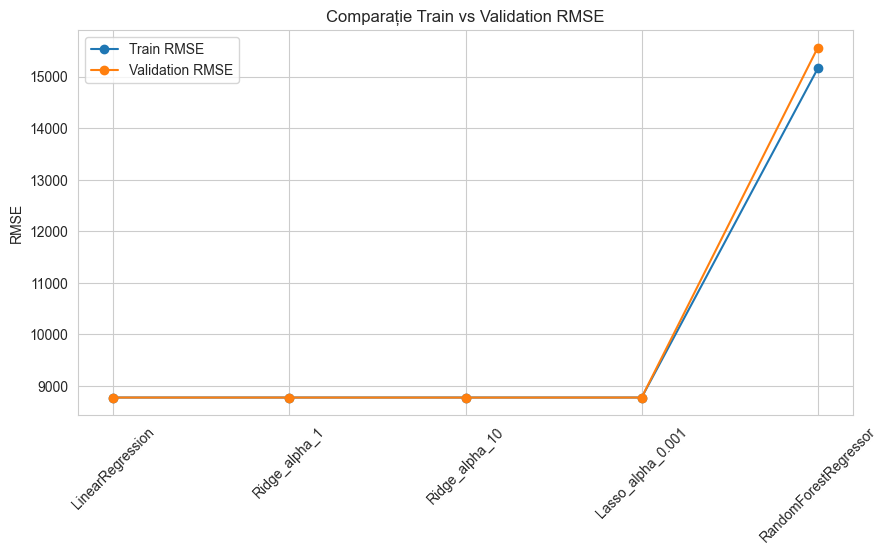

In [268]:
plt.figure(figsize=(10, 5))
plt.plot(train_val_regression_df["Model"], train_val_regression_df["Train_RMSE"], marker="o", label="Train RMSE")
plt.plot(train_val_regression_df["Model"], train_val_regression_df["Val_RMSE"], marker="o", label="Validation RMSE")
plt.xticks(rotation=45)
plt.title("Comparație Train vs Validation RMSE")
plt.ylabel("RMSE")
plt.legend()
plt.show()

## 5. Tabele comparative finale

## Tabel comparativ clasificare

In [269]:
display(classification_results_df)

,Model,Acuratețe,Precizie,Recall,F1
3,LogisticRegression,0.777750,0.709958,0.685770,0.696173
2,DecisionTree_leaf5,0.766500,0.701810,0.682289,0.691400
1,DecisionTree_depth10,0.764875,0.698908,0.679515,0.688560
4,RandomForest,0.751500,0.687742,0.640484,0.659222
0,DecisionTree_depth5,0.708000,0.640605,0.590069,0.610019


## Tabel comparativ regresie

In [270]:
display(regression_results_df)

,Model,MAE,MSE,RMSE,R2
2,Ridge_alpha_10,6820.873430,7.702505e+07,8776.391627,0.944740
1,Ridge_alpha_1,6822.300732,7.703385e+07,8776.893070,0.944733
0,LinearRegression,6822.609344,7.703617e+07,8777.025337,0.944732
3,Lasso_alpha_0.001,6822.801365,7.703826e+07,8777.144140,0.944730
4,RandomForestRegressor,12206.951173,2.421473e+08,15561.082804,0.826275


# Analiza importanței atributelor
## Importanța atributelor pentru RandomForestClassifie

,Feature,Importance
0,num__experience_years,0.198904
21,cat__education_level_PhD,0.170070
32,cat__company_size_Enterprise,0.099367
19,cat__education_level_High School,0.074116
50,cat__experience_bracket_high,0.068273
51,cat__experience_bracket_low,0.063971
20,cat__education_level_Master,0.046804
33,cat__company_size_Large,0.043595
18,cat__education_level_Diploma,0.040238
36,cat__company_size_Startup,0.035921


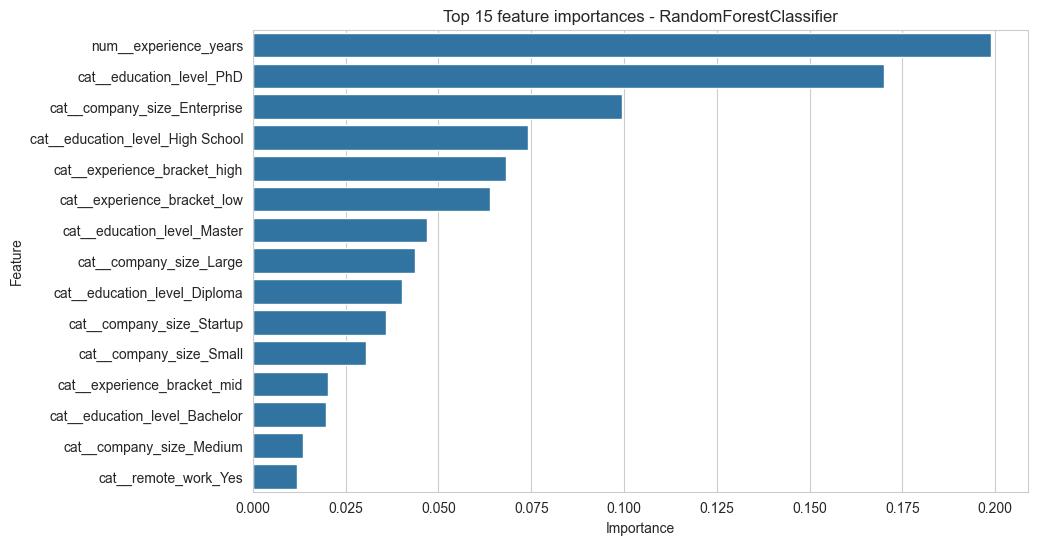

In [271]:
# Verific dacă modelul RandomForest există în dicționarul cu predicții
if "RandomForest" in classification_predictions:
    # Extrag pipeline-ul antrenat pentru RandomForest
    rf_clf = classification_predictions["RandomForest"]["pipeline"]

    # Obțin numele tuturor feature-urilor după preprocesare
    feature_names = rf_clf.named_steps["preprocessor"].get_feature_names_out()
    # Extrag importanța fiecărui feature din modelul RandomForest
    importances = rf_clf.named_steps["classifier"].feature_importances_

    # Construiesc un DataFrame cu numele feature-urilor și importanța lor
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    # Afișez primele 20 cele mai importante feature-uri
    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 feature importances - RandomForestClassifier")
    plt.show()

## Importanța atributelor pentru RandomForestRegressor

,Feature,Importance
40,cat__location_India,0.222319
0,num__experience_years,0.185756
32,cat__company_size_Enterprise,0.127857
46,cat__location_USA,0.093658
21,cat__education_level_PhD,0.075460
5,cat__job_title_AI Engineer,0.061702
33,cat__company_size_Large,0.060421
10,cat__job_title_Data Analyst,0.041782
38,cat__location_Canada,0.035293
7,cat__job_title_Business Analyst,0.031904


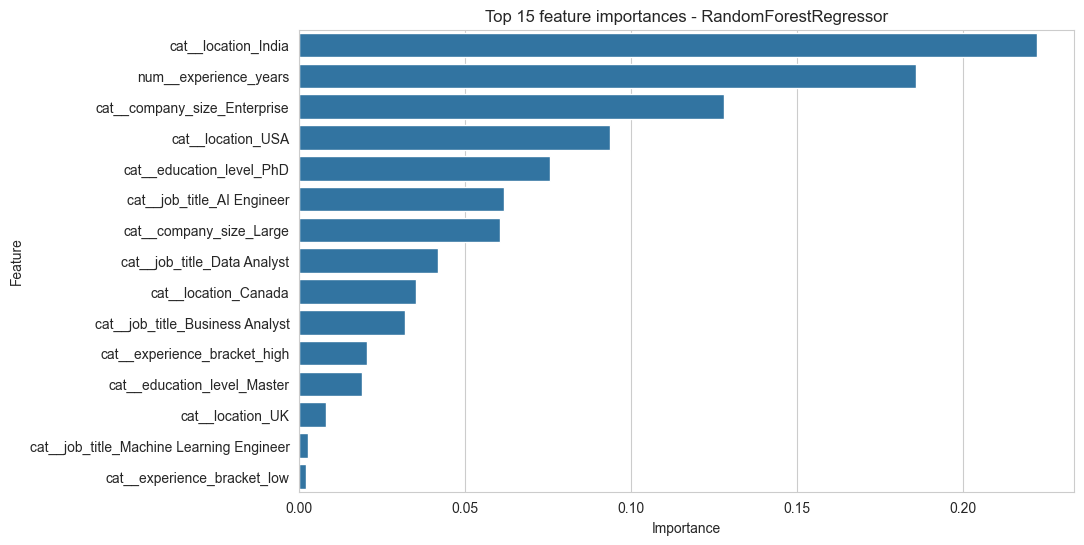

In [272]:
# Verific dacă modelul RandomForestRegressor există în dicționarul cu predicții
if "RandomForestRegressor" in regression_predictions:
    # Extrag pipeline-ul antrenat pentru RandomForestRegressor
    rf_reg = regression_predictions["RandomForestRegressor"]["pipeline"]

    # Obțin numele tuturor feature-urilor după preprocesare
    feature_names = rf_reg.named_steps["preprocessor"].get_feature_names_out()
    # Extrag importanța fiecărui feature din modelul RandomForestRegressor
    importances = rf_reg.named_steps["regressor"].feature_importances_

    # Construiesc un DataFrame cu feature-uri și importanța lor
    feature_importance_reg_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    # Afișez top 20 cele mai importante feature-uri
    display(feature_importance_reg_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_reg_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 feature importances - RandomForestRegressor")
    plt.show()

## Kaggle

In [273]:
# Citire set de test pentru clasificare
test_cls_df = pd.read_csv("CD_private_test.csv")


# Dacă există coloană id, o salvez separat
if "id" in test_cls_df.columns:
    test_cls_ids = test_cls_df["id"]

    # Elimin coloana id din datele de intrare ale modelului
    # deoarece nu este o caracteristică utilă
    X_private_cls_test = test_cls_df.drop(columns=["id"])
else:
    # Dacă nu există id, generăm noi ID-uri
    test_cls_ids = range(1, len(test_cls_df) + 1)

    # Folosim toate coloanele ca input pentru model
    X_private_cls_test = test_cls_df.copy()


# Predicții clasificare

# Folosesc pipeline-ul antrenat anterior (include preprocessing + model)
private_cls_pred_encoded = best_classification_pipeline.predict(X_private_cls_test)

# Transform etichetele numerice înapoi în text
private_cls_pred = label_encoder_cls.inverse_transform(private_cls_pred_encoded)


# Creare fișier submission

submission_cls = pd.DataFrame({
    "id": test_cls_ids,
    "prediction": private_cls_pred
})


# Salvez în format CSV pentru upload pe Kaggle
submission_cls.to_csv("submission_classification.csv", index=False)

# Afișez primele rezultate pentru verificare
display(submission_cls.head())

# Verific distribuția predicțiilor
display(submission_cls["prediction"].value_counts())

,id,prediction
0,1,No Vacation
1,2,No Vacation
2,3,No Vacation
3,4,No Vacation
4,5,No Vacation


prediction
No Vacation    5734
Small          3998
Medium         3415
Large          2853
Name: count, dtype: int64

In [274]:
# Citire set de test pentru regresie
test_reg_df = pd.read_csv("CD_private_test.csv")

# Dacă există coloană id, o salvez separat
if "id" in test_reg_df.columns:
    test_reg_ids = test_reg_df["id"]

    # Elimin coloana id din features
    X_private_reg_test = test_reg_df.drop(columns=["id"])
else:
    # Dacă nu există id, generez noi ID-uri
    test_reg_ids = range(1, len(test_reg_df) + 1)

    # Folosesc toate coloanele ca input
    X_private_reg_test = test_reg_df.copy()


# Predicții regresie

# Folosesc pipeline-ul de regresie antrenat anterior
private_reg_pred = best_regression_pipeline.predict(X_private_reg_test)


# Creare fișier submission
submission_reg = pd.DataFrame({
    "id": test_reg_ids,
    "prediction": private_reg_pred
})


# Salvez fișierul pentru Kaggle
submission_reg.to_csv("submission_regression.csv", index=False)

# Afișez primele rezultate pentru verificare
display(submission_reg.head())

,id,prediction
0,1,147417.299705
1,2,61191.691748
2,3,95592.162677
3,4,143450.364830
4,5,102417.133917
